Data Ingestion & Quality Profiling


In [1]:
#Read car_prices.csv into a pandas DataFrame.
import pandas as pd
df = pd.read_csv(r"C:\Users\Maanvi\OneDrive\Desktop\car_prices.csv")
#Display the first 5 rows.
df.head(5)

,year,make,model,trim,body,transmission,vin,state,condition,odometer,color,interior,seller,mmr,sellingprice,saledate
0,2015,Kia,Sorento,LX,SUV,automatic,5xyktca69fg566472,ca,5.0,16639.0,white,black,kia motors america inc,20500.0,21500.0,Tue Dec 16 2014 12:30:00 GMT-0800 (PST)
1,2015,Kia,Sorento,LX,SUV,automatic,5xyktca69fg561319,ca,5.0,9393.0,white,beige,kia motors america inc,20800.0,21500.0,Tue Dec 16 2014 12:30:00 GMT-0800 (PST)
2,2014,BMW,3 Series,328i SULEV,Sedan,automatic,wba3c1c51ek116351,ca,45.0,1331.0,gray,black,financial services remarketing (lease),31900.0,30000.0,Thu Jan 15 2015 04:30:00 GMT-0800 (PST)
3,2015,Volvo,S60,T5,Sedan,automatic,yv1612tb4f1310987,ca,41.0,14282.0,white,black,volvo na rep/world omni,27500.0,27750.0,Thu Jan 29 2015 04:30:00 GMT-0800 (PST)
4,2014,BMW,6 Series Gran Coupe,650i,Sedan,automatic,wba6b2c57ed129731,ca,43.0,2641.0,gray,black,financial services remarketing (lease),66000.0,67000.0,Thu Dec 18 2014 12:30:00 GMT-0800 (PST)


In [2]:
#Display data types and record count
df.dtypes

year              int64
make             object
model            object
trim             object
body             object
transmission     object
vin              object
state            object
condition       float64
odometer        float64
color            object
interior         object
seller           object
mmr             float64
sellingprice    float64
saledate         object
dtype: object

In [3]:
#Check the shape of the dataset (rows and columns).
df.shape

(558837, 16)

In [4]:
#Display column names and data types.
print(df.columns,df.dtypes)

Index(['year', 'make', 'model', 'trim', 'body', 'transmission', 'vin', 'state',
       'condition', 'odometer', 'color', 'interior', 'seller', 'mmr',
       'sellingprice', 'saledate'],
      dtype='object') year              int64
make             object
model            object
trim             object
body             object
transmission     object
vin              object
state            object
condition       float64
odometer        float64
color            object
interior         object
seller           object
mmr             float64
sellingprice    float64
saledate         object
dtype: object


In [5]:
#Quantify nulls per column; visualize with a bar chart or heatmap.
null_counts = df.isnull().sum()
print(null_counts)

year                0
make            10301
model           10399
trim            10651
body            13195
transmission    65352
vin                 4
state               0
condition       11820
odometer           94
color             749
interior          749
seller              0
mmr                38
sellingprice       12
saledate           12
dtype: int64


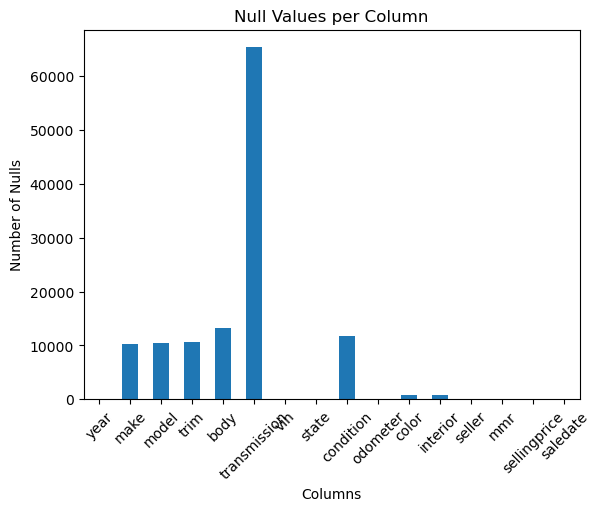

In [6]:
#visualization with a bar chart
import matplotlib.pyplot as plt

null_counts = df.isnull().sum()

plt.figure()
null_counts.plot(kind='bar')
plt.title("Null Values per Column")
plt.xlabel("Columns")
plt.ylabel("Number of Nulls")
plt.xticks(rotation=45)
plt.show()

In [7]:
#Count number of duplicate records and delete if any present
df.duplicated().sum()

np.int64(0)

Data frames Queries:

In [8]:
#Calculate the average, minimum, and maximum car price
# Average price
avg_price = df['sellingprice'].mean()

# Minimum price
min_price = df['sellingprice'].min()

# Maximum price
max_price = df['sellingprice'].max()

print("Average Price:", avg_price)
print("Minimum Price:", min_price)
print("Maximum Price:", max_price)

Average Price: 13611.358810003132
Minimum Price: 1.0
Maximum Price: 230000.0


In [9]:
#List all unique colors of cars
df['color'].unique

<bound method Series.unique of 0          white
1          white
2           gray
3          white
4           gray
           ...  
558832    silver
558833     white
558834     black
558835     white
558836      gray
Name: color, Length: 558837, dtype: object>

In [10]:
#Find the number of unique car brands and car models
brand_num = df['make'].unique
car_num = df['model'].unique
print("Total number of Brands:", brand_num)
print("Total number of Models:", car_num)

Total number of Brands: <bound method Series.unique of 0            Kia
1            Kia
2            BMW
3          Volvo
4            BMW
           ...  
558832       Kia
558833       Ram
558834       BMW
558835    Nissan
558836      Ford
Name: make, Length: 558837, dtype: object>
Total number of Models: <bound method Series.unique of 0                     Sorento
1                     Sorento
2                    3 Series
3                         S60
4         6 Series Gran Coupe
                 ...         
558832                   K900
558833                   2500
558834                     X5
558835                 Altima
558836                  F-150
Name: model, Length: 558837, dtype: object>


In [12]:
#Find all car information having selling prices greater than $165000
filtered_df = df[df['sellingprice'] > 165000]
print(filtered_df)

        year           make       model      trim   body transmission  \
125095  2012    Rolls-Royce       Ghost      Base  Sedan    automatic   
344905  2014           Ford      Escape  Titanium    SUV    automatic   
446949  2015  Mercedes-Benz     S-Class   S65 AMG  Sedan    automatic   
538347  2012    Rolls-Royce       Ghost      Base  sedan    automatic   
545523  2013    Rolls-Royce       Ghost      Base  sedan    automatic   
548169  2011        Ferrari  458 Italia      Base  coupe    automatic   
557570  2012    Rolls-Royce       Ghost       EWB  sedan    automatic   

                      vin state  condition  odometer  color interior  \
125095  sca664s58cux50727    fl       45.0   14316.0  black    beige   
344905  1fmcu9j98eua23833    mo       43.0   27802.0  green      tan   
446949  wddug7kb2fa102347    ca       41.0    5277.0  white    white   
538347  sca664s59cux50803    ca       44.0    5215.0  white      tan   
545523  sca664s52dux52152    fl       42.0    7852.0  w

In [13]:
#Find the top 5 most frequently sold car models
df['model'].value_counts().head(5)

model
Altima    19349
F-150     14479
Fusion    12946
Camry     12545
Escape    11861
Name: count, dtype: int64

In [15]:
#What is the average selling price of cars by brand (make)
avg_sel_price = df.groupby('make')['sellingprice'].mean()
print("Average Selling Price:", avg_sel_price)

Average Selling Price: make
Acura           14017.268260
Aston Martin    54812.000000
Audi            19915.432782
BMW             21441.895748
Bentley         74367.672414
                    ...     
subaru           3710.416667
suzuki           4810.000000
toyota           7339.105263
volkswagen       6145.833333
vw              13672.916667
Name: sellingprice, Length: 96, dtype: float64


In [16]:
#What is the minimum selling price of cars for each interior
Min_sell_interior = df.groupby('interior')['sellingprice'].min()
print("Minimum selling price of cars for each interior:", Min_sell_interior)

Minimum selling price of cars for each interior: interior
beige         100.0
black           1.0
blue          150.0
brown         200.0
burgundy      175.0
gold          250.0
gray            1.0
green         100.0
off-white     900.0
orange       1200.0
purple        200.0
red           200.0
silver        150.0
tan           100.0
white         350.0
yellow       3100.0
—             150.0
Name: sellingprice, dtype: float64


In [17]:
#Find highest odometer reading per year from highest to lowest order
Odometer_reading = df.groupby('year')['odometer'].max().sort_values(ascending=False)
print("Highest odometer reading per year from highest to lowest order:", Odometer_reading)

Highest odometer reading per year from highest to lowest order: year
1999    999999.0
2013    999999.0
2011    999999.0
2010    999999.0
2009    999999.0
2008    999999.0
2007    999999.0
2006    999999.0
2005    999999.0
2004    999999.0
2003    999999.0
2002    999999.0
2001    999999.0
2014    999999.0
1998    999999.0
1997    999999.0
1996    999999.0
1993    999999.0
2012    999999.0
2000    462579.0
1995    396793.0
1992    379307.0
1994    356402.0
1991    274149.0
1986    273327.0
1990    265498.0
1988    241751.0
1987    230946.0
1989    218052.0
1984    170799.0
1985    121644.0
2015    100454.0
1982     85738.0
1983     42697.0
Name: odometer, dtype: float64


In [18]:
#Create a new column for car age (assuming the current year is 2025)
df['car_age'] = 2025 - df['year']
df[['year', 'car_age']].head()

,year,car_age
0,2015,10
1,2015,10
2,2014,11
3,2015,10
4,2014,11


In [19]:
#Find the number of cars having a condition greater than or equal to 48 and odometer greater than 90000
count = df[(df['condition'] >= 48) & (df['odometer'] > 90000)].shape[0]

print("Number of cars:", count)

Number of cars: 746


In [25]:
# Which state consistently has higher car prices for newer cars(year>2013)
state_avg_price = new_cars.groupby('state')['sellingprice'].mean()
state_avg_price.sort_values(ascending=False)

state
oh                   28020.221053
ab                   25204.255319
nj                   24237.063973
on                   22962.560386
qc                   22722.938144
                         ...     
3vwd17aj5fm225953    13200.000000
3vwd17aj8fm239622    13200.000000
3vwd17aj4fm201708    13200.000000
3vwd17aj3fm276741    13200.000000
ok                   10600.000000
Name: sellingprice, Length: 64, dtype: float64

In [28]:
#For cars with excellent condition (top 20%), which makes have the lowest average price (value for money)
result = (
    df[df['condition'] >= df['condition'].quantile(0.80)]
    .groupby('make')['sellingprice']
    .mean()
    .sort_values()
    .reset_index()
)

result.columns = ['Make', 'Avg_Price']
print(result.head(10))

         Make    Avg_Price
0       Isuzu  1125.000000
1  Oldsmobile  1910.000000
2       honda  4233.333333
3      Saturn  5700.406504
4      subaru  6200.000000
5    chrysler  6225.000000
6       smart  6835.759494
7       mazda  7275.000000
8     Pontiac  7686.824324
9        Saab  7711.111111


Data Visualization and insights:

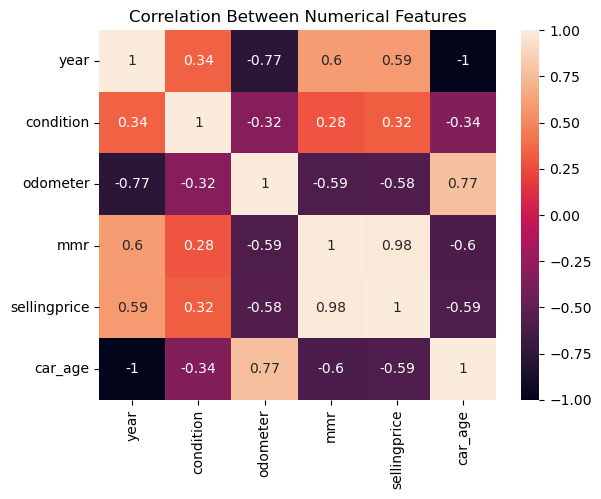

In [29]:
#Show the correlation of all the features(columns) having numerical values(e.g. selling price, odometer).
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure()
sns.heatmap(df.corr(numeric_only=True), annot=True)
plt.title("Correlation Between Numerical Features")
plt.show()

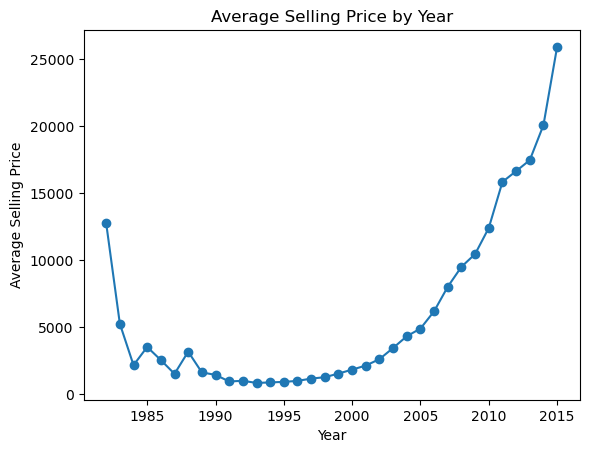

In [31]:
#Plot a graph to show the average selling price by year and explain the pattern you notice from the graph. Which plot will you use bar or scatter
import matplotlib.pyplot as plt
avg_price_year = df.groupby('year')['sellingprice'].mean().reset_index()
plt.figure()
plt.plot(avg_price_year['year'], avg_price_year['sellingprice'], marker='o')

plt.xlabel("Year")
plt.ylabel("Average Selling Price")
plt.title("Average Selling Price by Year")

plt.show()
#Analysis
#Upward trend - Newer cars have higher prices
#Older years - Lower average price (depreciation effect)
#The line plot shows a clear upward trend in average selling price as the manufacturing year increases. 
#This indicates that newer cars command higher prices, which aligns with depreciation principles. 
#Older cars tend to have significantly lower average prices due to wear and mileage.”

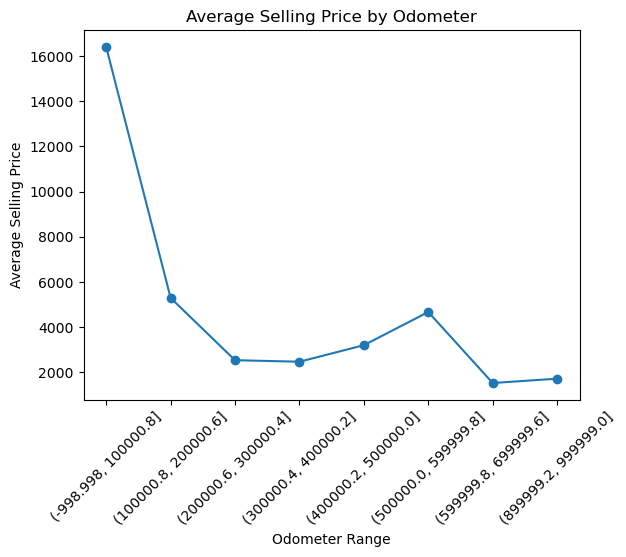

In [39]:
# Plot a graph to show average selling price by odometer and explain the trend you notice from the graph.

avg_price_odo = (
    df.groupby('odo_bin', observed=True)['sellingprice']
    .mean()
    .reset_index()
)
plt.figure()
plt.plot(avg_price_odo['odo_bin'].astype(str), avg_price_odo['sellingprice'], marker='o')

plt.xticks(rotation=45)
plt.xlabel("Odometer Range")
plt.ylabel("Average Selling Price")
plt.title("Average Selling Price by Odometer")

plt.show()

#Analysis
#As odometer increases → price decreases
#High mileage cars = cheaper
#“The graph shows a clear negative trend between odometer and average selling price.
#Cars with lower mileage have significantly higher prices, while prices decrease as mileage increases.
#The decline is steep in early mileage ranges and gradually flattens at higher odometer values, 
#indicating depreciation slows down over time.”

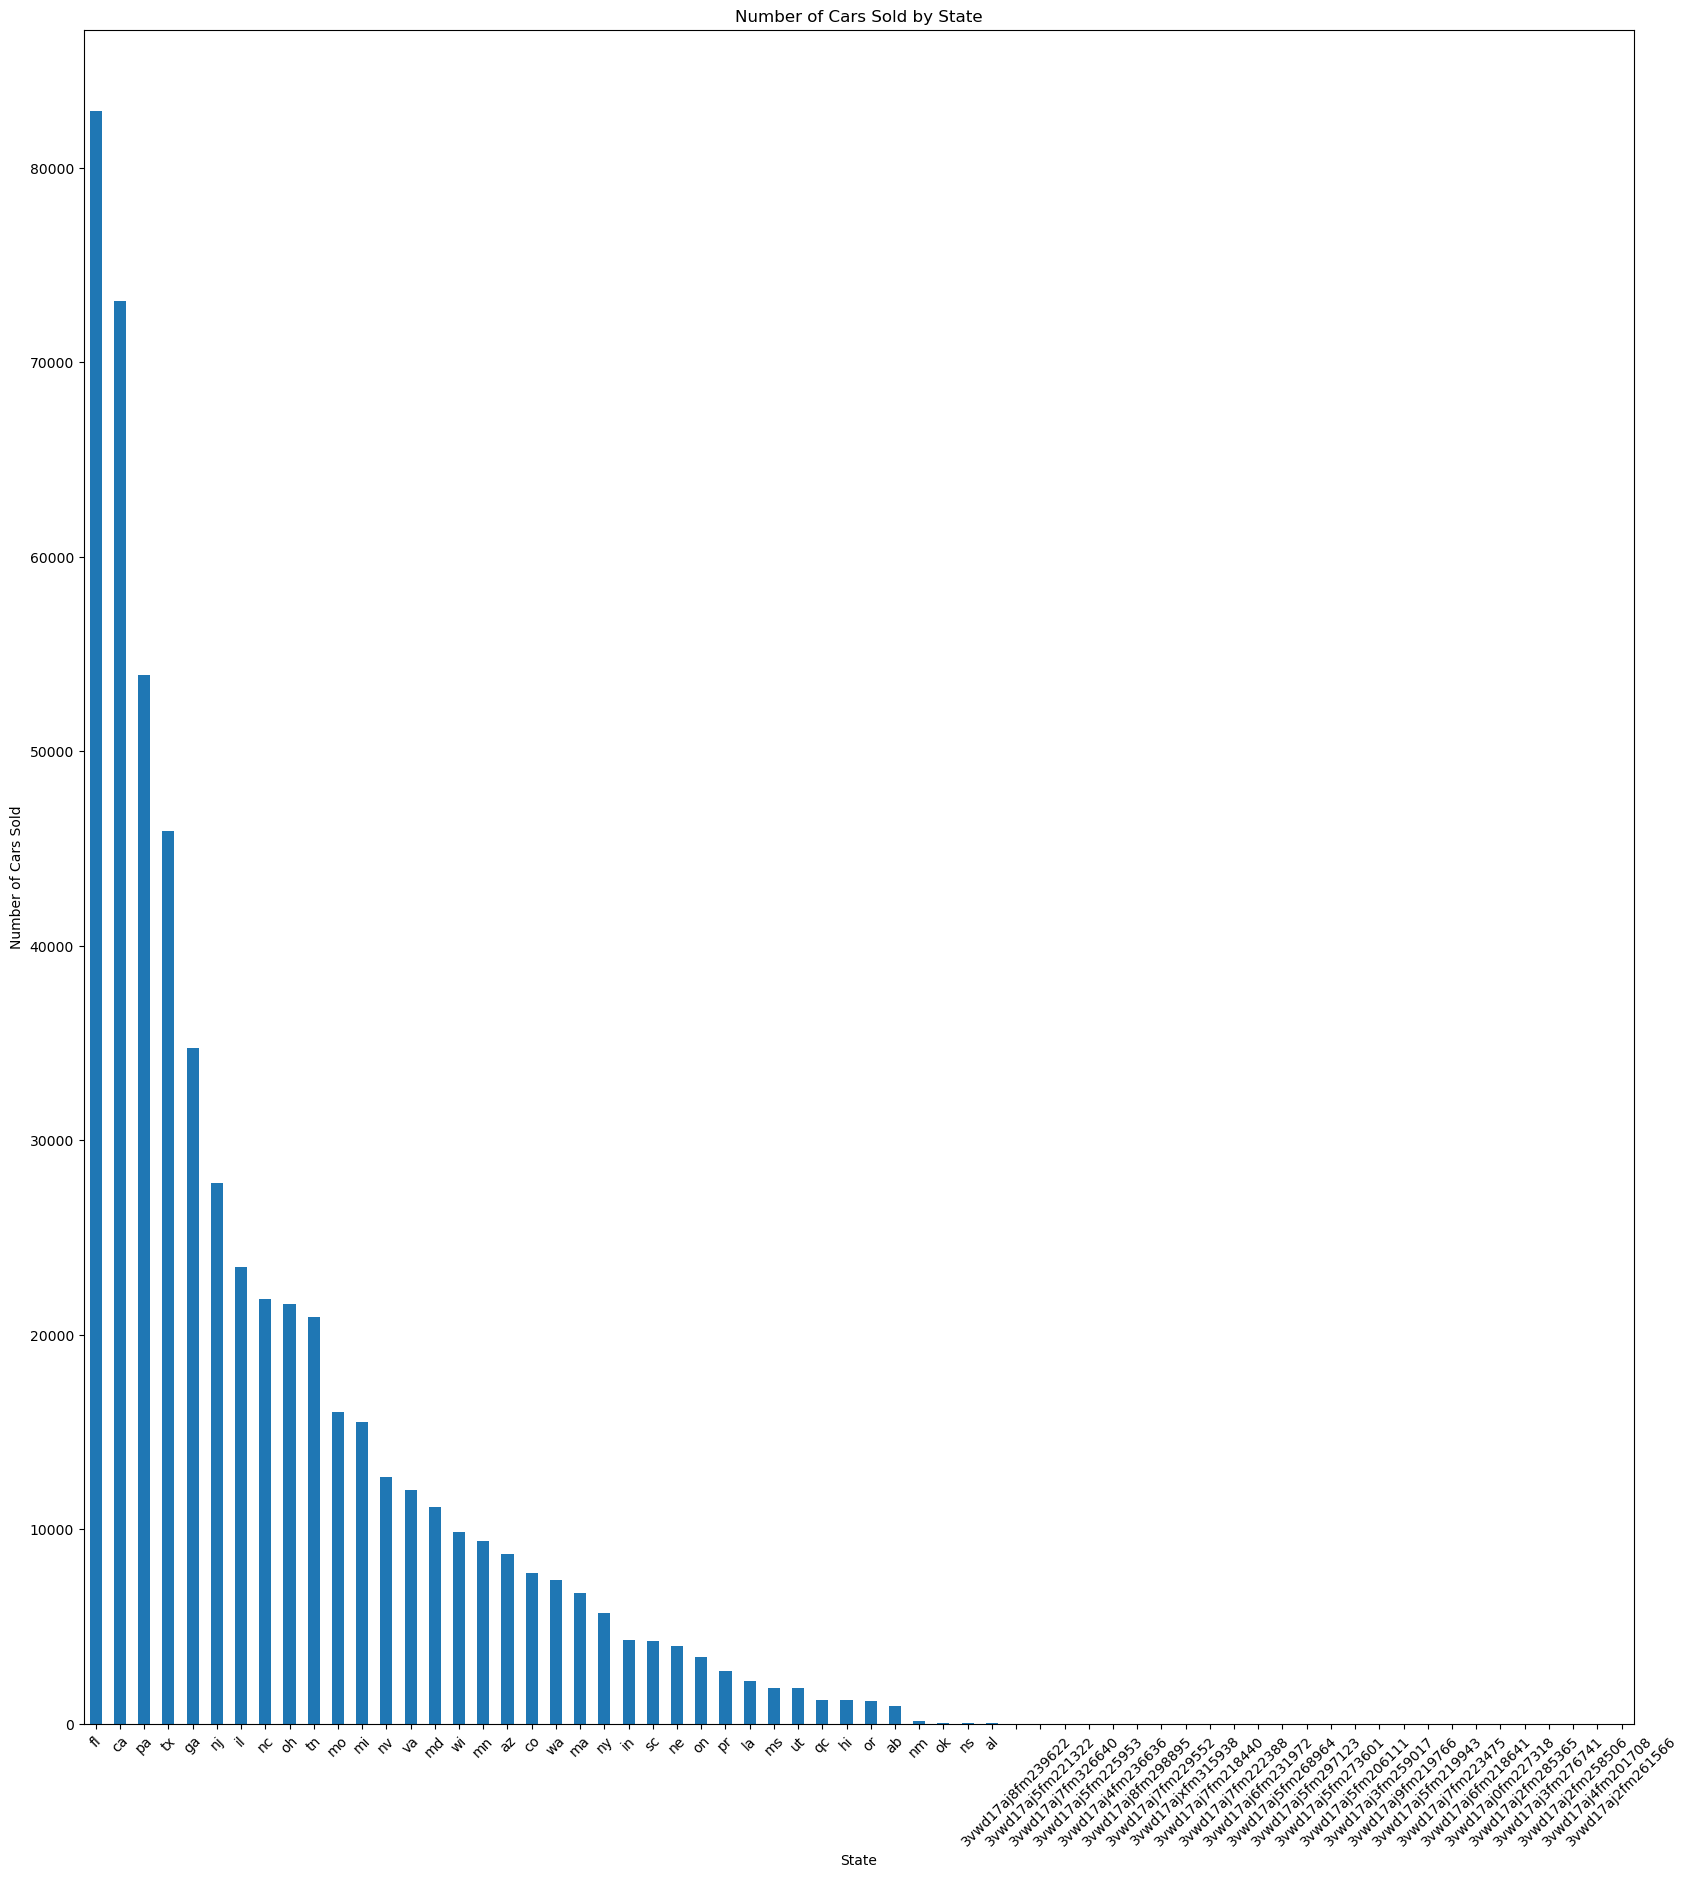

In [43]:
#Plot a graph to show the number of cars sold in each state. Find the top three highest car selling states by having a look at the graph.
state_counts = df['state'].value_counts()
plt.figure(figsize=(20,22))
state_counts.plot(kind='bar')

plt.xlabel("State")
plt.ylabel("Number of Cars Sold")
plt.title("Number of Cars Sold by State")

plt.xticks(rotation=45)
plt.show()


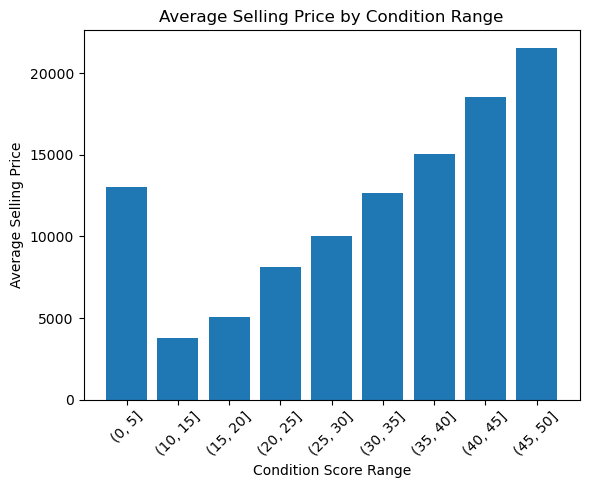

In [44]:
# Plot a bar graph of average selling price by condition score ranges of size 5. Give a summary of the insights.
df['condition_bin'] = pd.cut(df['condition'], bins=range(0, 105, 5))
avg_price_cond = (
    df.groupby('condition_bin', observed=True)['sellingprice']
    .mean()
    .reset_index()
)
plt.figure()
plt.bar(avg_price_cond['condition_bin'].astype(str), avg_price_cond['sellingprice'])

plt.xticks(rotation=45)
plt.xlabel("Condition Score Range")
plt.ylabel("Average Selling Price")
plt.title("Average Selling Price by Condition Range")

plt.show()

#Insights
#“The bar chart shows a clear positive relationship between condition score and average selling price.
#As the condition improves in increments of 5, the average price consistently increases. 
#The highest condition ranges exhibit a sharp rise in price, indicating that well-maintained cars command a premium in the market.”

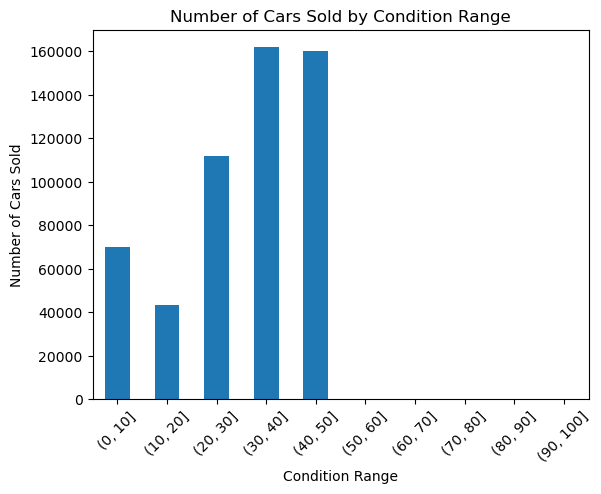

In [45]:
#Plot a bar graph of no. of cars sold by condition ranges of size 10. Give some insights from the graph.
df['condition_bin'] = pd.cut(df['condition'], bins=range(0, 110, 10))
condition_counts = df['condition_bin'].value_counts().sort_index()
plt.figure()
condition_counts.plot(kind='bar')

plt.xlabel("Condition Range")
plt.ylabel("Number of Cars Sold")
plt.title("Number of Cars Sold by Condition Range")

plt.xticks(rotation=45)
plt.show()

#Insights
#“The bar chart shows that most cars are concentrated in mid-condition ranges, indicating a typical used car market.
#Very low-condition cars are rare, while high-condition cars are also fewer, suggesting limited availability of premium-quality vehicles.
#The distribution appears slightly bell-shaped, with the majority of cars in moderate condition ranges.”

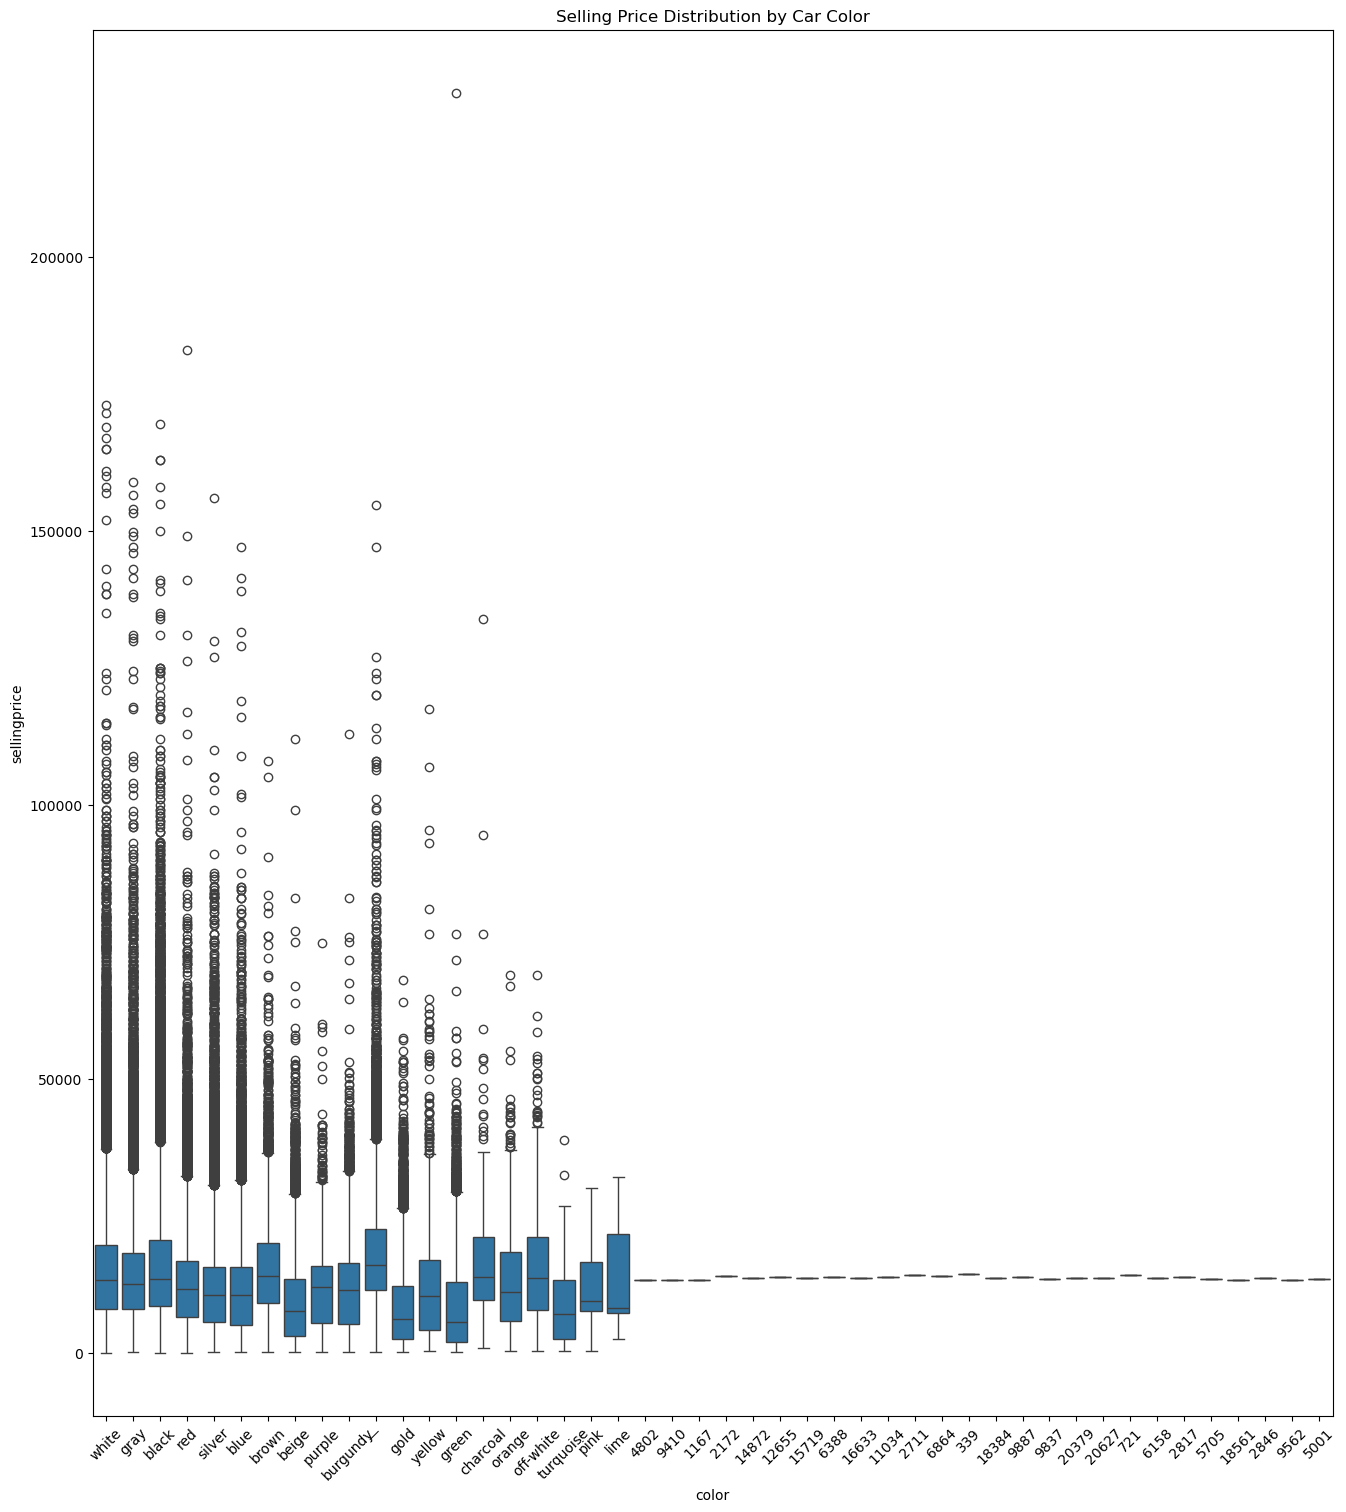

In [49]:
#Plot a box plot to show the distribution of car selling prices grouped by color. Extract insights and if required, remove outliers and plot the graph
#again.
plt.figure(figsize = (16, 18))
sns.boxplot(x='color', y='sellingprice', data=df)

plt.xticks(rotation=45)
plt.title("Selling Price Distribution by Car Color")
plt.show()

In [51]:
#Removing outliers
Q1 = df['sellingprice'].quantile(0.25)
Q3 = df['sellingprice'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

df_clean = df[(df['sellingprice'] >= lower_bound) & (df['sellingprice'] <= upper_bound)]

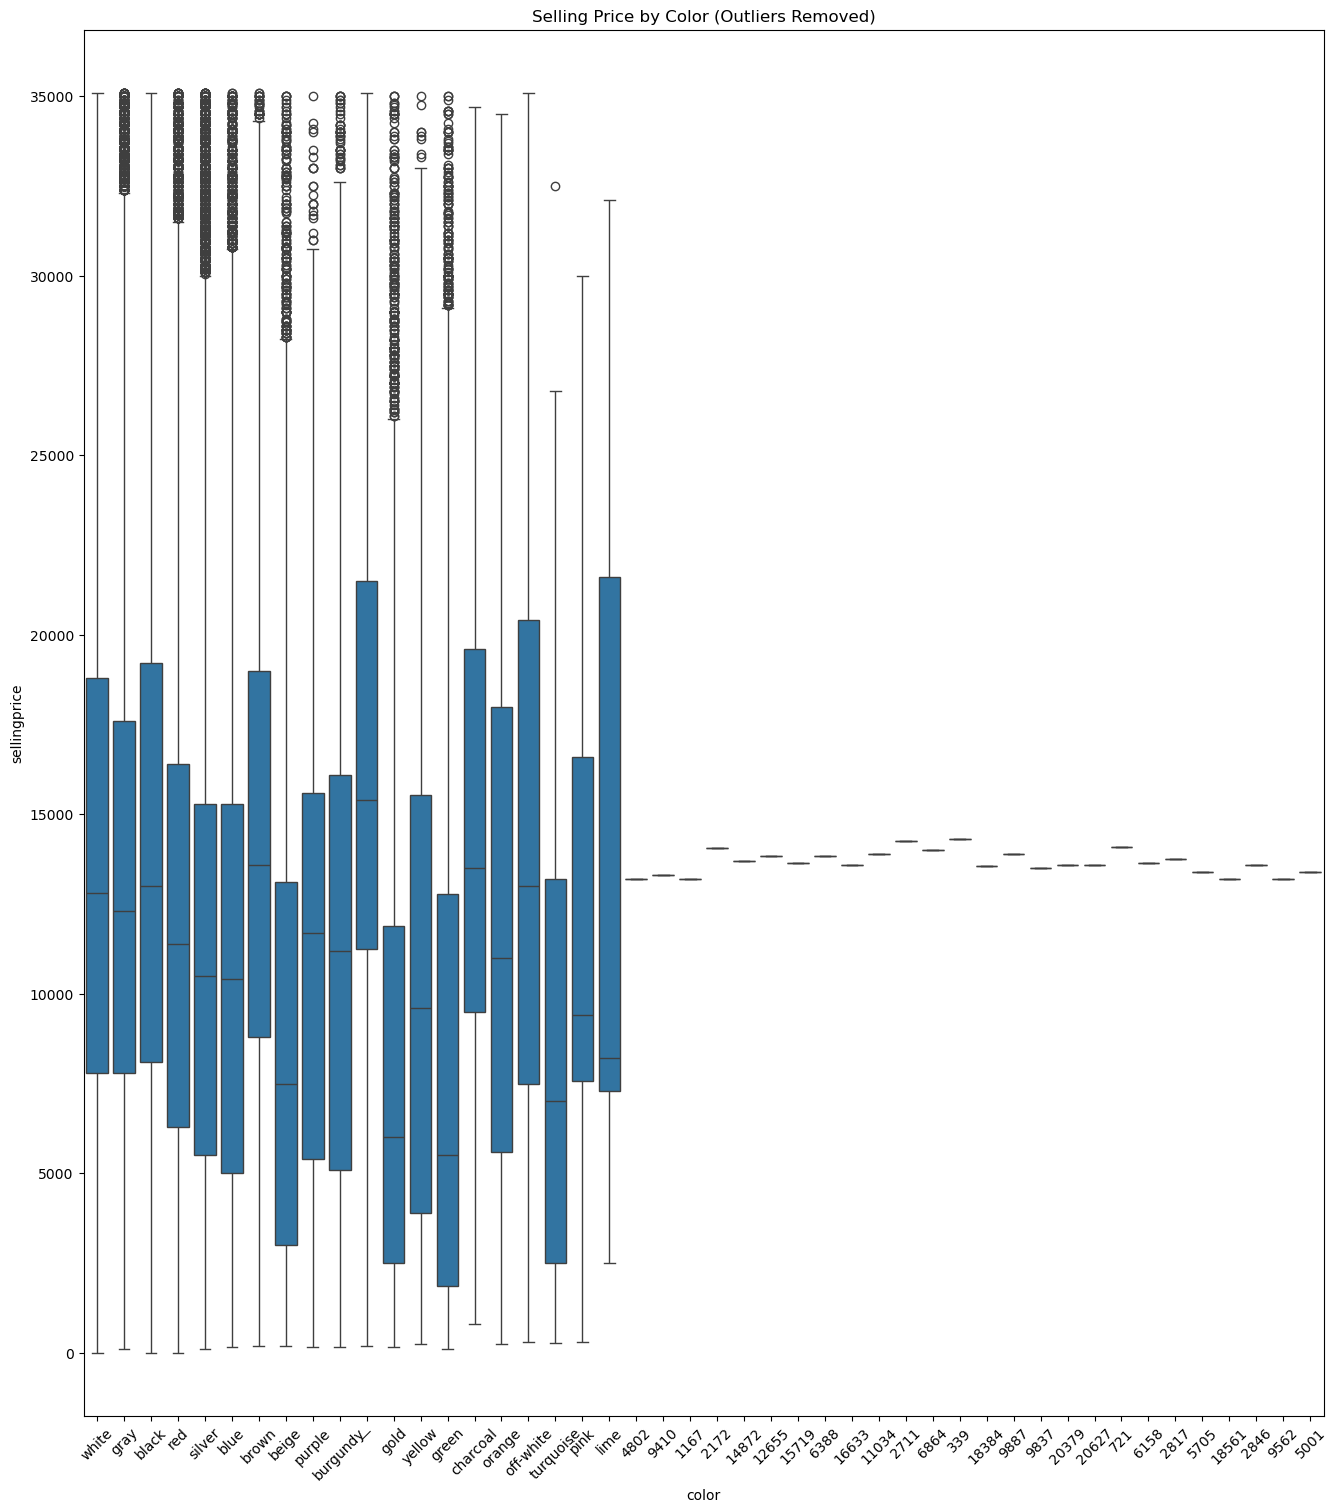

In [53]:
#Plotting again after removal of outliers
plt.figure(figsize= (16, 18))
sns.boxplot(x='color', y='sellingprice', data=df_clean)

plt.xticks(rotation=45)
plt.title("Selling Price by Color (Outliers Removed)")
plt.show()

#Insights
#“The box plot shows the distribution of selling prices across different car colors. 
#Some colors exhibit higher median prices, possibly indicating market preference or association with premium vehicles. 
#Significant outliers were observed, representing luxury cars. 
#After removing outliers using the IQR method, the distribution becomes more stable and allows for clearer comparison across colors.”